Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import shap

In [ ]:
df = pd.read_csv("/content/Vehicle Collision.csv")

/tmp/ipython-input-3211822235.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Vehicle Collision.csv")


In [ ]:
df.head()

,UNIQUE_ID,COLLISION_ID,CRASH_DATE,CRASH_TIME,PERSON_ID,PERSON_TYPE,PERSON_INJURY,VEHICLE_ID,PERSON_AGE,EJECTION,...,BODILY_INJURY,POSITION_IN_VEHICLE,SAFETY_EQUIPMENT,PED_LOCATION,PED_ACTION,COMPLAINT,PED_ROLE,CONTRIBUTING_FACTOR_1,CONTRIBUTING_FACTOR_2,PERSON_SEX
0,10253606,4230743.0,10/24/2019,19:15,84bcb3a7-d201-4c61-9e30-fe29268c1074,Occupant,Injured,19143343.0,27.0,Not Ejected,...,Back,Driver,Lap Belt & Harness,NaN,NaN,Complaint of Pain or Nausea,Driver,NaN,NaN,M
1,10248708,4229547.0,10/26/2019,1:15,a8904763-2870-42f3-865c-b53d8e5156e2,Pedestrian,Injured,NaN,24.0,NaN,...,Shoulder - Upper Arm,NaN,NaN,Pedestrian/Bicyclist/Other Pedestrian at Inter...,Crossing With Signal,None Visible,Pedestrian,Unspecified,Unspecified,F
2,10254556,4230715.0,10/26/2019,8:50,1a085543-ae9d-4a69-8cd0-fb7b33380a8b,Bicyclist,Injured,19143832.0,42.0,Not Ejected,...,Knee-Lower Leg Foot,Driver,Unknown,NaN,NaN,None Visible,Driver,NaN,NaN,M
3,10250834,4230376.0,10/26/2019,19:40,f58fc41f-497e-4f30-bf49-a9a80adec8b2,Bicyclist,Injured,19141949.0,36.0,Not Ejected,...,Back,Driver,NaN,NaN,NaN,Internal,Driver,NaN,NaN,M
4,10252474,4229773.0,10/26/2019,16:50,4bf13d12-8d7a-4cb0-997f-dd6a8b1adca6,Occupant,Injured,19142773.0,50.0,Not Ejected,...,Head,"Front passenger, if two or more persons, inclu...",Lap Belt & Harness,NaN,NaN,Complaint of Pain or Nausea,Passenger,NaN,NaN,F


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230660 entries, 0 to 230659
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   UNIQUE_ID              230660 non-null  object 
 1   COLLISION_ID           230656 non-null  float64
 2   CRASH_DATE             230656 non-null  object 
 3   CRASH_TIME             230656 non-null  object 
 4   PERSON_ID              230653 non-null  object 
 5   PERSON_TYPE            230656 non-null  object 
 6   PERSON_INJURY          230656 non-null  object 
 7   VEHICLE_ID             181937 non-null  float64
 8   PERSON_AGE             229663 non-null  float64
 9   EJECTION               102787 non-null  object 
 10  EMOTIONAL_STATUS       126918 non-null  object 
 11  BODILY_INJURY          126959 non-null  object 
 12  POSITION_IN_VEHICLE    102906 non-null  object 
 13  SAFETY_EQUIPMENT       90120 non-null   object 
 14  PED_LOCATION           26292 non-nul

In [ ]:
df.isnull().sum()

,0
UNIQUE_ID,0
COLLISION_ID,4
CRASH_DATE,4
CRASH_TIME,4
PERSON_ID,7
PERSON_TYPE,4
PERSON_INJURY,4
VEHICLE_ID,48723
PERSON_AGE,997
EJECTION,127873


Data Preprocessing

In [ ]:
df.drop(['UNIQUE_ID', 'COLLISION_ID', 'CRASH_DATE', 'CRASH_TIME', 'PERSON_ID', 'VEHICLE_ID'], axis=1, inplace=True)

In [ ]:

df['PERSON_AGE'] = pd.to_numeric(df['PERSON_AGE'], errors='coerce')


df['PERSON_AGE'].fillna(df['PERSON_AGE'].mean(), inplace=True)


df.fillna('Unknown', inplace=True)

/tmp/ipython-input-639724647.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PERSON_AGE'].fillna(df['PERSON_AGE'].mean(), inplace=True)


Exploratory Data Analysis (EDA)

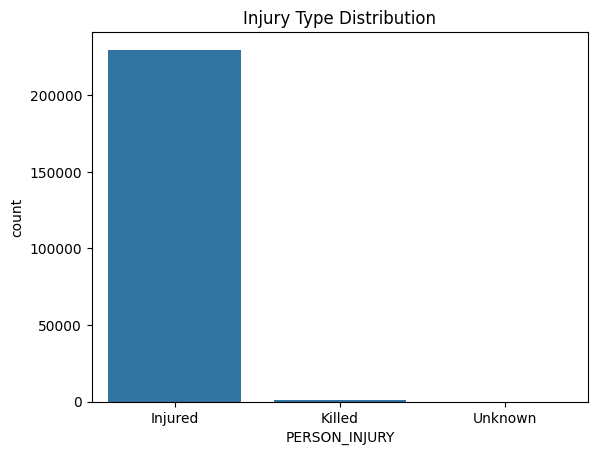

In [ ]:
sns.countplot(data=df, x='PERSON_INJURY', order=df['PERSON_INJURY'].value_counts().index)
plt.title("Injury Type Distribution")
plt.show()


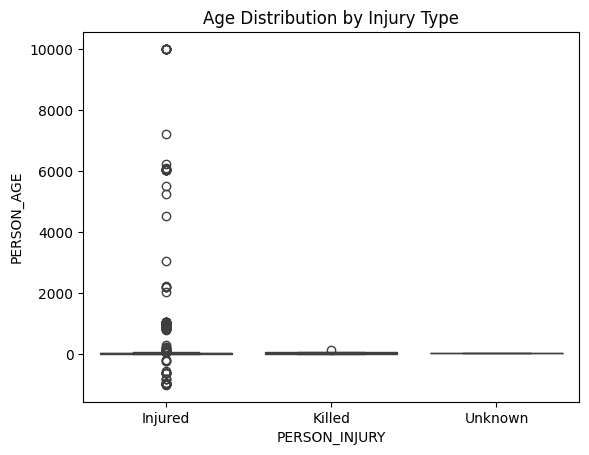

In [ ]:

df['PERSON_AGE'] = pd.to_numeric(df['PERSON_AGE'], errors='coerce')

sns.boxplot(data=df, x='PERSON_INJURY', y='PERSON_AGE')
plt.title("Age Distribution by Injury Type")
plt.show()

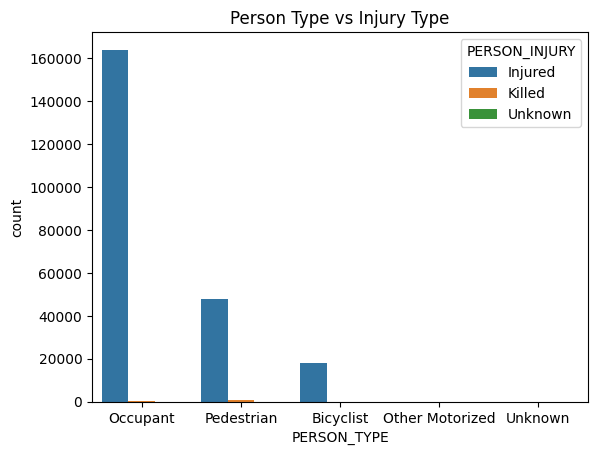

In [ ]:
sns.countplot(data=df, x='PERSON_TYPE', hue='PERSON_INJURY')
plt.title("Person Type vs Injury Type")
plt.show()

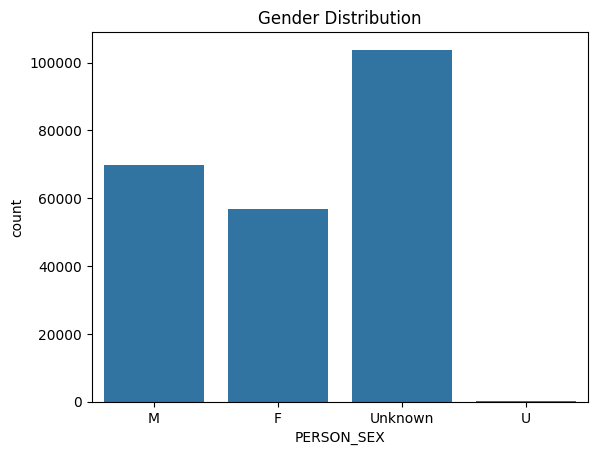

In [ ]:
sns.countplot(data=df, x='PERSON_SEX')
plt.title("Gender Distribution")
plt.show()

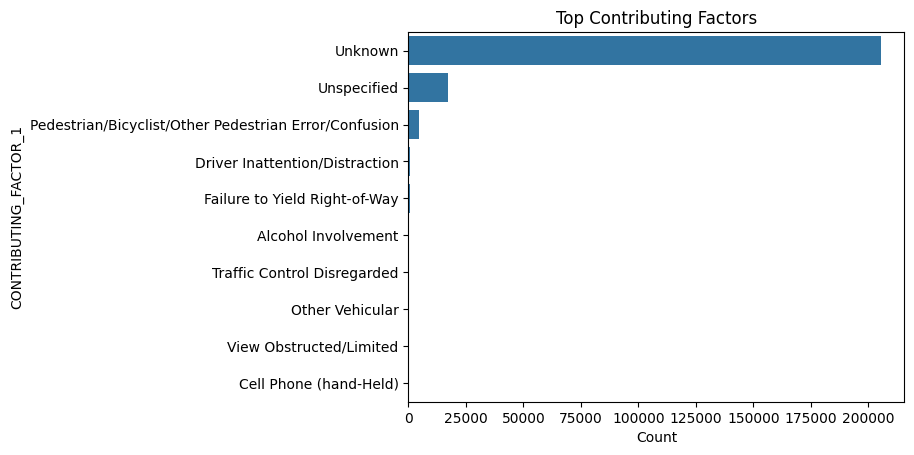

In [ ]:
top_factors = df['CONTRIBUTING_FACTOR_1'].value_counts().head(10)
sns.barplot(x=top_factors.values, y=top_factors.index)
plt.title("Top Contributing Factors")
plt.xlabel("Count")
plt.show()

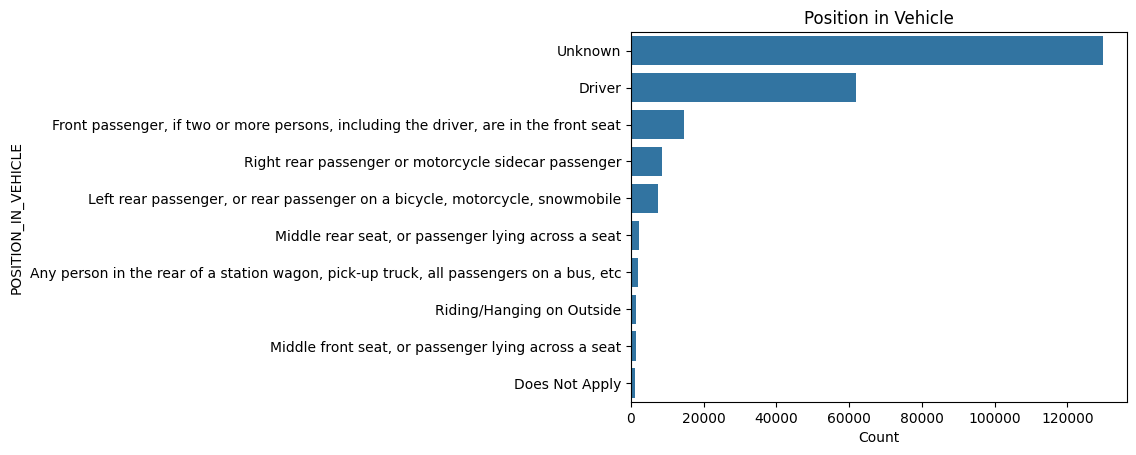

In [ ]:
top_positions = df['POSITION_IN_VEHICLE'].value_counts().head(10)
sns.barplot(x=top_positions.values, y=top_positions.index)
plt.title("Position in Vehicle")
plt.xlabel("Count")
plt.show()

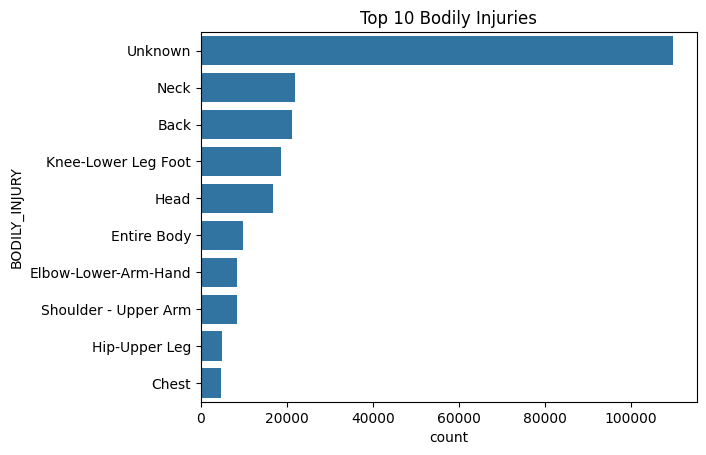

In [ ]:
sns.countplot(y='BODILY_INJURY', data=df, order=df['BODILY_INJURY'].value_counts().head(10).index)
plt.title("Top 10 Bodily Injuries")
plt.show()

LABEL ENCODE

In [ ]:

df['SEVERITY_LABEL'] = df['PERSON_INJURY'].apply(lambda x: 1 if x in ['Injured', 'Killed'] else 0)

print(df['SEVERITY_LABEL'].value_counts())


SEVERITY_LABEL
1    230656
0         4
Name: count, dtype: int64


In [ ]:
categorical_cols = [
    'PERSON_TYPE', 'PERSON_SEX', 'SAFETY_EQUIPMENT', 'EJECTION',
    'POSITION_IN_VEHICLE', 'PED_LOCATION', 'PED_ACTION',
    'COMPLAINT', 'PED_ROLE', 'CONTRIBUTING_FACTOR_1', 'CONTRIBUTING_FACTOR_2',
    'EMOTIONAL_STATUS', 'BODILY_INJURY'
]

In [ ]:
df_encoded = df.copy()


df_encoded['PERSON_AGE'] = pd.to_numeric(df_encoded['PERSON_AGE'], errors='coerce')

df_encoded['PERSON_AGE'].fillna(df_encoded['PERSON_AGE'].mean(), inplace=True)

In [ ]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

In [ ]:
print(df_encoded[categorical_cols + ['SEVERITY_LABEL']].head())

   PERSON_TYPE  PERSON_SEX  SAFETY_EQUIPMENT  EJECTION  POSITION_IN_VEHICLE  \
0            1           1                11         2                    2   
1            3           0                15         5                   10   
2            0           1                15         2                    2   
3            0           1                15         2                    2   
4            1           0                11         2                    3   

   PED_LOCATION  PED_ACTION  COMPLAINT  PED_ROLE  CONTRIBUTING_FACTOR_1  \
0             3          14          3         0                     45   
1             2           1         14         4                     48   
2             3          14         14         0                     45   
3             3          14         10         0                     45   
4             3          14          3         3                     45   

   CONTRIBUTING_FACTOR_2  EMOTIONAL_STATUS  BODILY_INJURY  SEVERITY_LABEL 

Model Selection & Training

In [ ]:
X = df_encoded.drop(columns=['SEVERITY_LABEL', 'PERSON_INJURY'])
y = df_encoded['SEVERITY_LABEL']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [00:58:00] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
models = {
    'Logistic Regression': log_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n📌 Model: {name}")
    print(classification_report(y_test, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_test, y_proba))



📌 Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00     46131

    accuracy                           1.00     46132
   macro avg       0.50      0.50      0.50     46132
weighted avg       1.00      1.00      1.00     46132

ROC AUC Score: 0.9778240228913312

📌 Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00     46131

    accuracy                           1.00     46132
   macro avg       1.00      1.00      1.00     46132
weighted avg       1.00      1.00      1.00     46132

ROC AUC Score: 1.0

📌 Model: XGBoost
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00     46131

    accuracy                           1.00     46132
   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


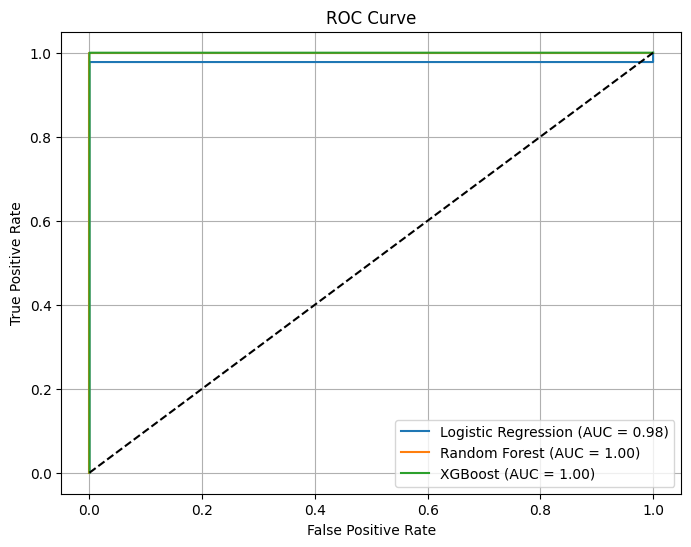

In [ ]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_proba):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


 93%|=================== | 42998/46132 [00:14<00:01]       

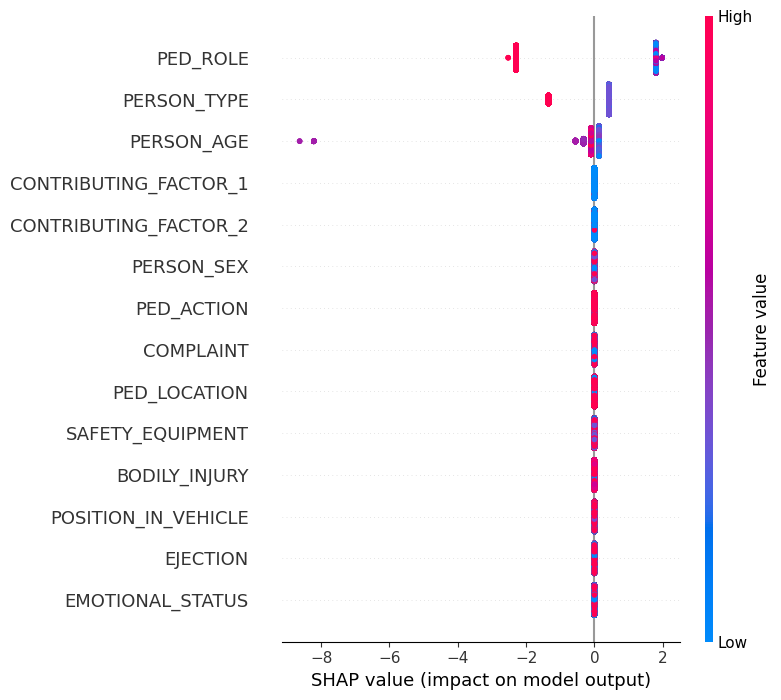

In [ ]:

explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


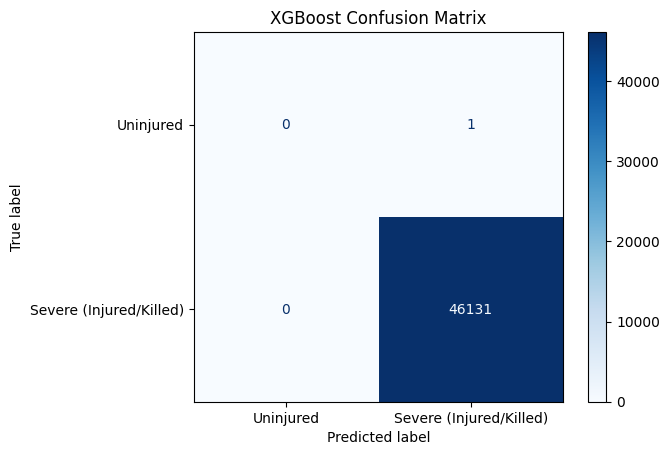

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = xgb_model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Uninjured", "Severe (Injured/Killed)"], cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.show()
